In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'Deepfake' in file or '.h5' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Deepfake_MobileNetV2_Final.h5
/content/drive/MyDrive/Deepfake_TwoStream_Final.h5
/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5
/content/drive/MyDrive/Deepfake_TwoStream3_Final.zip


In [ ]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/Deepfake_TwoStream3_Final.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/')

print("Done!")

Done!


Loading Model...


Saving OIP.webp to OIP (2).webp

------------------------
Prediction: AI GENERATED
Confidence: 0.9998784177732887
------------------------


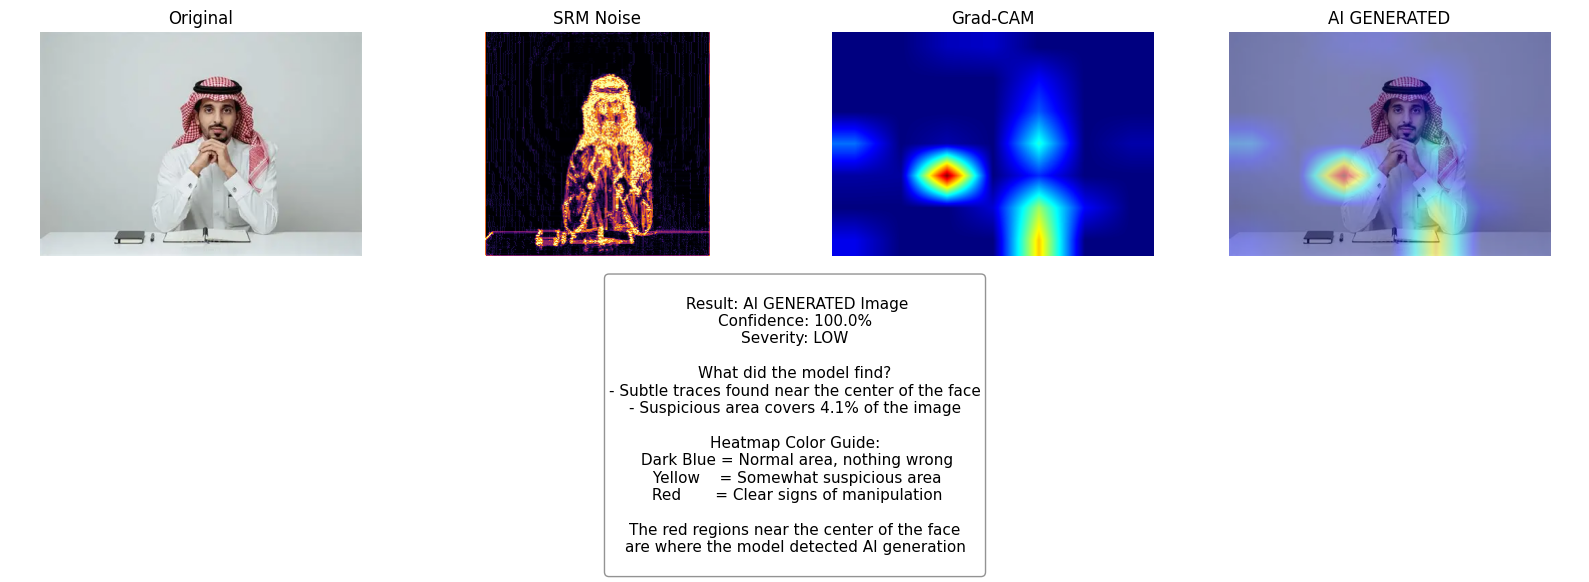

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files


# 1) SRM Layer
class SRMFilterLayer(tf.keras.layers.Layer):
    def init(self, **kwargs):
        super(SRMFilterLayer, self).init(**kwargs)

    def build(self, input_shape):
        filter_1 = np.array([[0,0,0],[-1,1,0],[0,0,0]], dtype=np.float32)
        filter_2 = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32)
        filter_3 = np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=np.float32)

        stacked = np.stack([filter_1, filter_2, filter_3], axis=-1)

        num_input_channels = input_shape[-1]
        kernel = np.zeros((3,3,num_input_channels,3), dtype=np.float32)

        for i in range(3):
            for c in range(num_input_channels):
                kernel[:,:,c,i] = stacked[:,:,i]

        for i in range(3):
            norm = np.sum(np.abs(kernel[:,:,:,i]))
            if norm > 0:
                kernel[:,:,:,i] /= norm

        self.srm_kernel = self.add_weight(
            name='srm_filters',
            shape=kernel.shape,
            initializer=tf.keras.initializers.Constant(kernel),
            trainable=False
        )
        super(SRMFilterLayer, self).build(input_shape)

    def call(self, inputs):
        noise = tf.nn.conv2d(inputs, self.srm_kernel, strides=1, padding='SAME')
        return tf.clip_by_value(noise, -3.0, 3.0)


# 2) Load Model
print("Loading Model...")
model_path = '/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5'

model = tf.keras.models.load_model(
    model_path,
    custom_objects={'SRMFilterLayer': SRMFilterLayer}
)

IMG_SIZE = (224, 224)


# 3) Layers
mobilenet_layer = [l for l in model.layers if 'mobilenet' in l.name.lower()][0]
rgb_gap_layer = model.get_layer('rgb_gap')
stream_merge = model.get_layer('stream_merge')
head_dense = model.get_layer('head_dense')
head_bn = model.get_layer('head_bn')
head_dropout = model.get_layer('head_dropout')
head_output = model.get_layer('head_output')

srm_branch = tf.keras.Model(model.input, model.get_layer('srm_gap').output)
srm_vis_model = tf.keras.Model(model.input, model.get_layer('srm_filter').output)


# 4) Image prep
def prepare_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Image not found")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    img = cv2.resize(img, IMG_SIZE)
    img = np.expand_dims(img.astype(np.float32), axis=0)

    return original, tf.convert_to_tensor(img)


# 5) GradCAM
def make_gradcam(img_tensor):

    srm_vec = srm_branch(img_tensor, training=False)

    with tf.GradientTape() as tape:
        features = mobilenet_layer(img_tensor, training=False)
        tape.watch(features)

        rgb_vec = rgb_gap_layer(features)
        merged = stream_merge([rgb_vec, srm_vec])

        x = head_dense(merged)
        x = head_bn(x, training=False)
        x = head_dropout(x, training=False)
        preds = head_output(x)

        score = preds[0,0]

    grads = tape.gradient(score, features)

    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    features = features[0]

    heatmap = tf.reduce_sum(features * pooled, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) > 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()


# 6) SRM noise
def get_srm_noise(img_tensor):
    noise = srm_vis_model(img_tensor, training=False).numpy()[0]
    noise = np.mean(np.abs(noise), axis=-1)

    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
    return noise


# 7) overlay
def overlay_heatmap(original, heatmap):

    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return heatmap, cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)


# 8) prediction
def explain(score):
    if score > 0.5:
        return "REAL", score, f"Real: {score*100:.2f}% | AI: {(1-score)*100:.2f}%"
    else:
        return "AI GENERATED", 1-score, f"AI: {(1-score)*100:.2f}% | Real: {score*100:.2f}%"


# 9) Smart explanation
def generate_smart_explanation(heatmap, label, conf):
    h, w = heatmap.shape
    high = heatmap > 0.6
    ratio = np.sum(high) / heatmap.size

    regions = {
        "left side of the face": np.sum(high[:, :w//3]),
        "center of the face": np.sum(high[:, w//3:2*w//3]),
        "right side of the face": np.sum(high[:, 2*w//3:])
    }
    main_region = max(regions, key=regions.get)

    if label == "REAL":
        if ratio > 0.1:
            heatmap_note = f"""⚠️ Note: The heatmap shows some activation
→ Model is confident it's real, but pay attention
→ Suspicious area: {ratio*100:.1f}% of the image
→ Focus region: {main_region}"""
        else:
            heatmap_note = """Your heatmap is fully dark blue
→ The model found zero suspicious regions"""

        return f"""
 Result: REAL Image
Confidence: {conf*100:.1f}%

Why is it real?
- No pixel manipulation was detected
- Colors and gradients look natural
- No AI generation artifacts found

Heatmap Color Guide:
 Dark Blue = Nothing suspicious here
 Yellow    = Slightly unusual area
 Red       = Highly suspicious area

{heatmap_note}
"""

    else:
        if ratio > 0.3:
            detail = "Manipulation covers most of the image"
            severity = "HIGH"
        elif ratio > 0.1:
            detail = f"Manipulation detected mainly in the {main_region}"
            severity = "MEDIUM"
        else:
            detail = f"Subtle traces found near the {main_region}"
            severity = "LOW"

        return f"""
 Result: AI GENERATED Image
Confidence: {conf*100:.1f}%
Severity: {severity}

What did the model find?
- {detail}
- Suspicious area covers {ratio*100:.1f}% of the image

Heatmap Color Guide:
 Dark Blue = Normal area, nothing wrong
 Yellow    = Somewhat suspicious area
 Red       = Clear signs of manipulation

The red regions near the {main_region}
are where the model detected AI generation
"""


# 10) MAIN
def predict_and_visualize(path):

    original, img_tensor = prepare_image(path)

    score = float(model.predict(img_tensor, verbose=0)[0][0])
    label, conf, details = explain(score)

    heatmap = make_gradcam(img_tensor)
    noise = get_srm_noise(img_tensor)
    heatmap_overlay, overlay = overlay_heatmap(original, heatmap)

    smart_text = generate_smart_explanation(heatmap, label, conf)

    print("\n------------------------")
    print("Prediction:", label)
    print("Confidence:", conf)
    print("------------------------")

    plt.figure(figsize=(16,6))

    plt.subplot(2,4,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.imshow(noise, cmap="inferno")
    plt.title("SRM Noise")
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.imshow(heatmap_overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.imshow(overlay)
    plt.title(label)
    plt.axis("off")

    plt.subplot(2,1,2)
    plt.text(
        0.5,
        0.5,
        smart_text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            facecolor='white',
            alpha=0.85,
            edgecolor='gray',
            boxstyle='round'
        )
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# 11) Upload
def upload_and_predict():
    uploaded = files.upload()

    for name in uploaded.keys():
        predict_and_visualize(name)


upload_and_predict()

Loading Model...


Saving positive-man-on-clean-background-photo.jpg to positive-man-on-clean-background-photo (3).jpg

------------------------
Prediction: REAL
Confidence: 0.7987725138664246
------------------------


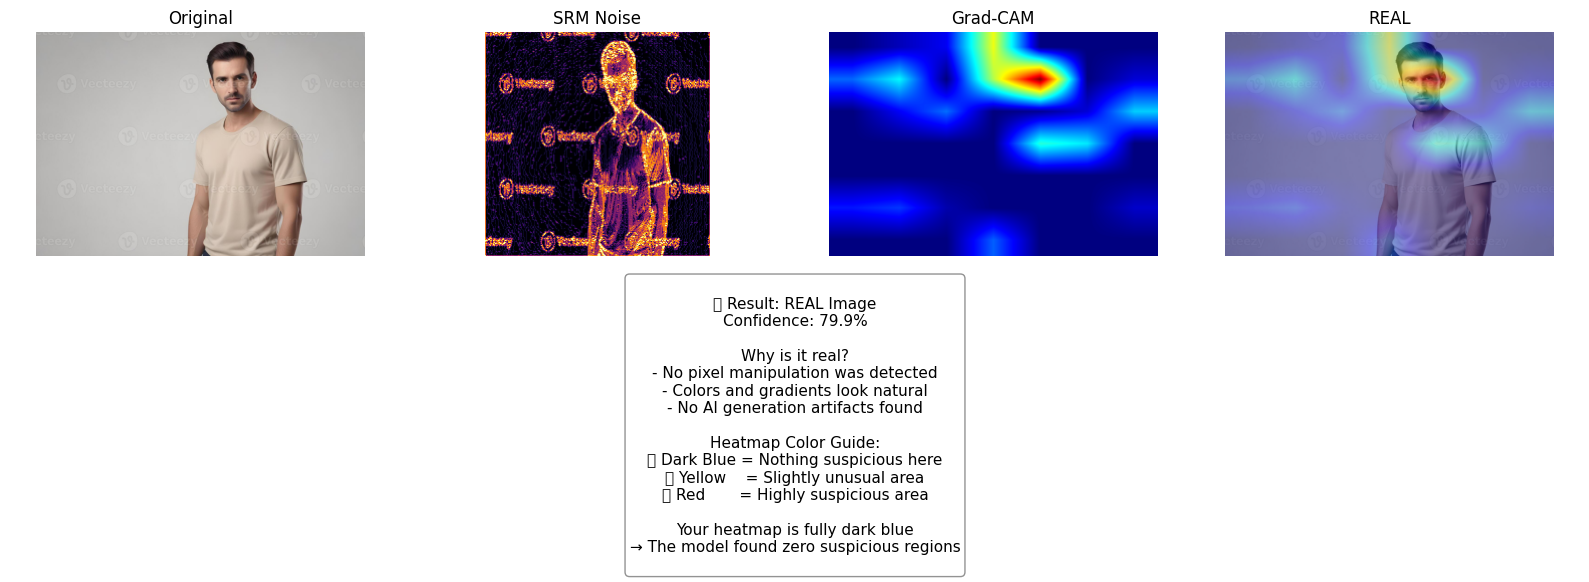

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files


# 1) SRM Layer
class SRMFilterLayer(tf.keras.layers.Layer):
    def init(self, **kwargs):
        super(SRMFilterLayer, self).init(**kwargs)

    def build(self, input_shape):
        filter_1 = np.array([[0,0,0],[-1,1,0],[0,0,0]], dtype=np.float32)
        filter_2 = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32)
        filter_3 = np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=np.float32)

        stacked = np.stack([filter_1, filter_2, filter_3], axis=-1)

        num_input_channels = input_shape[-1]
        kernel = np.zeros((3,3,num_input_channels,3), dtype=np.float32)

        for i in range(3):
            for c in range(num_input_channels):
                kernel[:,:,c,i] = stacked[:,:,i]

        for i in range(3):
            norm = np.sum(np.abs(kernel[:,:,:,i]))
            if norm > 0:
                kernel[:,:,:,i] /= norm

        self.srm_kernel = self.add_weight(
            name='srm_filters',
            shape=kernel.shape,
            initializer=tf.keras.initializers.Constant(kernel),
            trainable=False
        )
        super(SRMFilterLayer, self).build(input_shape)

    def call(self, inputs):
        noise = tf.nn.conv2d(inputs, self.srm_kernel, strides=1, padding='SAME')
        return tf.clip_by_value(noise, -3.0, 3.0)


# 2) Load Model
print("Loading Model...")
model_path = '/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5'

model = tf.keras.models.load_model(
    model_path,
    custom_objects={'SRMFilterLayer': SRMFilterLayer}
)

IMG_SIZE = (224, 224)


# 3) Layers
mobilenet_layer = [l for l in model.layers if 'mobilenet' in l.name.lower()][0]
rgb_gap_layer = model.get_layer('rgb_gap')
stream_merge = model.get_layer('stream_merge')
head_dense = model.get_layer('head_dense')
head_bn = model.get_layer('head_bn')
head_dropout = model.get_layer('head_dropout')
head_output = model.get_layer('head_output')

srm_branch = tf.keras.Model(model.input, model.get_layer('srm_gap').output)
srm_vis_model = tf.keras.Model(model.input, model.get_layer('srm_filter').output)


# 4) Image prep
def prepare_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Image not found")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    img = cv2.resize(img, IMG_SIZE)
    img = np.expand_dims(img.astype(np.float32), axis=0)

    return original, tf.convert_to_tensor(img)


# 5) GradCAM
def make_gradcam(img_tensor):

    srm_vec = srm_branch(img_tensor, training=False)

    with tf.GradientTape() as tape:
        features = mobilenet_layer(img_tensor, training=False)
        tape.watch(features)

        rgb_vec = rgb_gap_layer(features)
        merged = stream_merge([rgb_vec, srm_vec])

        x = head_dense(merged)
        x = head_bn(x, training=False)
        x = head_dropout(x, training=False)
        preds = head_output(x)

        score = preds[0,0]

    grads = tape.gradient(score, features)

    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    features = features[0]

    heatmap = tf.reduce_sum(features * pooled, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) > 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()


# 6) SRM noise
def get_srm_noise(img_tensor):
    noise = srm_vis_model(img_tensor, training=False).numpy()[0]
    noise = np.mean(np.abs(noise), axis=-1)

    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
    return noise


# 7) overlay
def overlay_heatmap(original, heatmap):

    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return heatmap, cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)


# 8) prediction
def explain(score):
    if score > 0.5:
        return "REAL", score, f"Real: {score*100:.2f}% | AI: {(1-score)*100:.2f}%"
    else:
        return "AI GENERATED", 1-score, f"AI: {(1-score)*100:.2f}% | Real: {score*100:.2f}%"


# 9) Smart explanation
def generate_smart_explanation(heatmap, label, conf):
    h, w = heatmap.shape
    high = heatmap > 0.6
    ratio = np.sum(high) / heatmap.size

    regions = {
        "left side of the face": np.sum(high[:, :w//3]),
        "center of the face": np.sum(high[:, w//3:2*w//3]),
        "right side of the face": np.sum(high[:, 2*w//3:])
    }
    main_region = max(regions, key=regions.get)

    if label == "REAL":
        if ratio > 0.05:
            heatmap_note = f"""⚠️ Note: The heatmap shows some activation
→ Model is confident it's real, but pay attention
→ Suspicious area: {ratio*100:.1f}% of the image
→ Focus region: {main_region}"""
        else:
            heatmap_note = """Your heatmap is fully dark blue
→ The model found zero suspicious regions"""

        return f"""
✅ Result: REAL Image
Confidence: {conf*100:.1f}%

Why is it real?
- No pixel manipulation was detected
- Colors and gradients look natural
- No AI generation artifacts found

Heatmap Color Guide:
🔵 Dark Blue = Nothing suspicious here
🟡 Yellow    = Slightly unusual area
🔴 Red       = Highly suspicious area

{heatmap_note}
"""

    else:
        if ratio > 0.3:
            detail = "Manipulation covers most of the image"
            severity = "HIGH"
        elif ratio > 0.05:
            detail = f"Manipulation detected mainly in the {main_region}"
            severity = "MEDIUM"
        else:
            detail = f"Subtle traces found near the {main_region}"
            severity = "LOW"

        return f"""
 Result: AI GENERATED Image
Confidence: {conf*100:.1f}%
Severity: {severity}

What did the model find?
- {detail}
- Suspicious area covers {ratio*100:.1f}% of the image

Heatmap Color Guide:
Dark Blue = Normal area, nothing wrong
 Yellow    = Somewhat suspicious area
 Red       = Clear signs of manipulation

The red regions near the {main_region}
are where the model detected AI generation
"""
# 10) MAIN
def predict_and_visualize(path):

    original, img_tensor = prepare_image(path)

    score = float(model.predict(img_tensor, verbose=0)[0][0])
    label, conf, details = explain(score)

    heatmap = make_gradcam(img_tensor)
    noise = get_srm_noise(img_tensor)
    heatmap_overlay, overlay = overlay_heatmap(original, heatmap)

    smart_text = generate_smart_explanation(heatmap, label, conf)

    print("\n------------------------")
    print("Prediction:", label)
    print("Confidence:", conf)
    print("------------------------")

    plt.figure(figsize=(16,6))

    plt.subplot(2,4,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.imshow(noise, cmap="inferno")
    plt.title("SRM Noise")
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.imshow(heatmap_overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.imshow(overlay)
    plt.title(label)
    plt.axis("off")

    plt.subplot(2,1,2)
    plt.text(
        0.5,
        0.5,
        smart_text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            facecolor='white',
            alpha=0.85,
            edgecolor='gray',
            boxstyle='round'
        )
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# 11) Upload
def upload_and_predict():
    uploaded = files.upload()

    for name in uploaded.keys():
        predict_and_visualize(name)


upload_and_predict()

Loading Model...


Saving OIP (1).webp to OIP (1) (1).webp

------------------------
Prediction: REAL
Confidence: 0.9999722838401794
------------------------


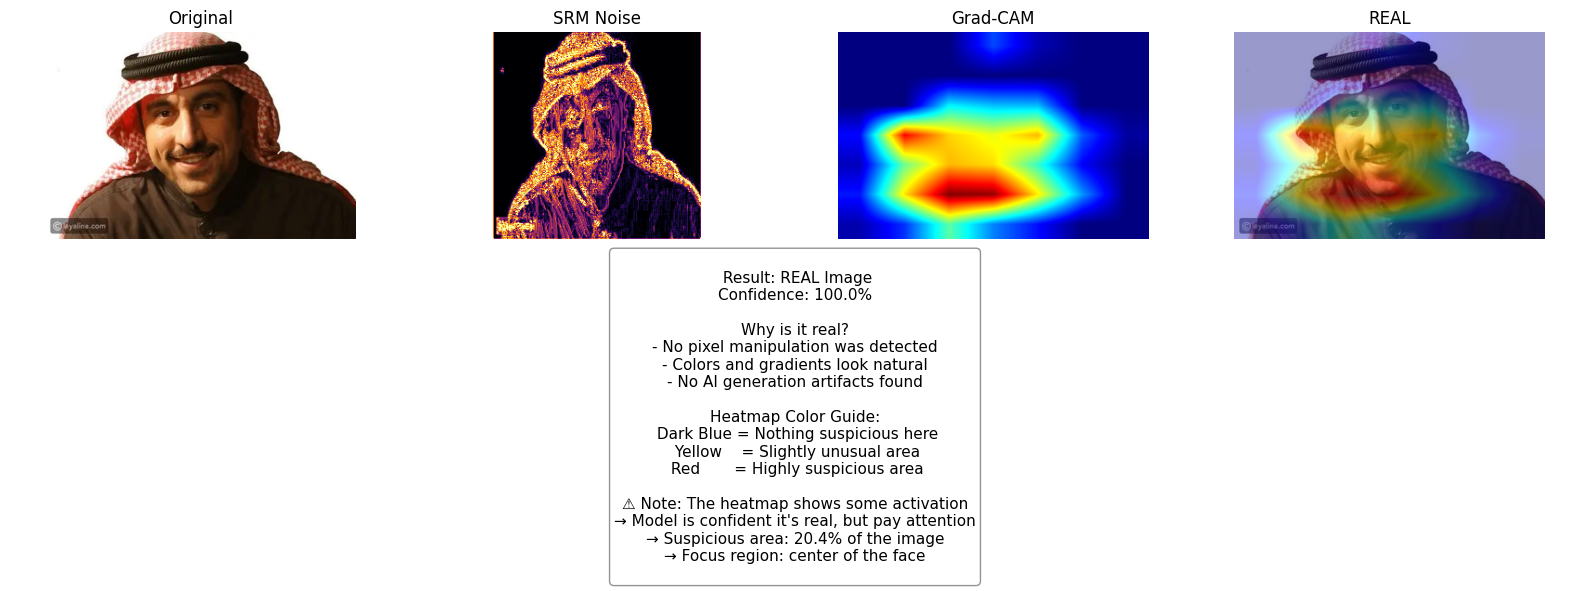

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files


# 1) SRM Layer
class SRMFilterLayer(tf.keras.layers.Layer):
    def init(self, **kwargs):
        super(SRMFilterLayer, self).init(**kwargs)

    def build(self, input_shape):
        filter_1 = np.array([[0,0,0],[-1,1,0],[0,0,0]], dtype=np.float32)
        filter_2 = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32)
        filter_3 = np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=np.float32)

        stacked = np.stack([filter_1, filter_2, filter_3], axis=-1)

        num_input_channels = input_shape[-1]
        kernel = np.zeros((3,3,num_input_channels,3), dtype=np.float32)

        for i in range(3):
            for c in range(num_input_channels):
                kernel[:,:,c,i] = stacked[:,:,i]

        for i in range(3):
            norm = np.sum(np.abs(kernel[:,:,:,i]))
            if norm > 0:
                kernel[:,:,:,i] /= norm

        self.srm_kernel = self.add_weight(
            name='srm_filters',
            shape=kernel.shape,
            initializer=tf.keras.initializers.Constant(kernel),
            trainable=False
        )
        super(SRMFilterLayer, self).build(input_shape)

    def call(self, inputs):
        noise = tf.nn.conv2d(inputs, self.srm_kernel, strides=1, padding='SAME')
        return tf.clip_by_value(noise, -3.0, 3.0)


# 2) Load Model
print("Loading Model...")
model_path = '/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5'

model = tf.keras.models.load_model(
    model_path,
    custom_objects={'SRMFilterLayer': SRMFilterLayer}
)

IMG_SIZE = (224, 224)


# 3) Layers
mobilenet_layer = [l for l in model.layers if 'mobilenet' in l.name.lower()][0]
rgb_gap_layer = model.get_layer('rgb_gap')
stream_merge = model.get_layer('stream_merge')
head_dense = model.get_layer('head_dense')
head_bn = model.get_layer('head_bn')
head_dropout = model.get_layer('head_dropout')
head_output = model.get_layer('head_output')

srm_branch = tf.keras.Model(model.input, model.get_layer('srm_gap').output)
srm_vis_model = tf.keras.Model(model.input, model.get_layer('srm_filter').output)


# 4) Image prep
def prepare_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Image not found")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    img = cv2.resize(img, IMG_SIZE)
    img = np.expand_dims(img.astype(np.float32), axis=0)

    return original, tf.convert_to_tensor(img)


# 5) GradCAM
def make_gradcam(img_tensor):

    srm_vec = srm_branch(img_tensor, training=False)

    with tf.GradientTape() as tape:
        features = mobilenet_layer(img_tensor, training=False)
        tape.watch(features)

        rgb_vec = rgb_gap_layer(features)
        merged = stream_merge([rgb_vec, srm_vec])

        x = head_dense(merged)
        x = head_bn(x, training=False)
        x = head_dropout(x, training=False)
        preds = head_output(x)

        score = preds[0,0]

    grads = tape.gradient(score, features)

    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    features = features[0]

    heatmap = tf.reduce_sum(features * pooled, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) > 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()


# 6) SRM noise
def get_srm_noise(img_tensor):
    noise = srm_vis_model(img_tensor, training=False).numpy()[0]
    noise = np.mean(np.abs(noise), axis=-1)

    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
    return noise


# 7) overlay
def overlay_heatmap(original, heatmap):

    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return heatmap, cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)


# 8) prediction
def explain(score):
    if score > 0.5:
        return "REAL", score, f"Real: {score*100:.2f}% | AI: {(1-score)*100:.2f}%"
    else:
        return "AI GENERATED", 1-score, f"AI: {(1-score)*100:.2f}% | Real: {score*100:.2f}%"


# 9) Smart explanation
def generate_smart_explanation(heatmap, label, conf):
    h, w = heatmap.shape
    high = heatmap > 0.6
    ratio = np.sum(high) / heatmap.size

    regions = {
        "left side of the face": np.sum(high[:, :w//3]),
        "center of the face": np.sum(high[:, w//3:2*w//3]),
        "right side of the face": np.sum(high[:, 2*w//3:])
    }
    main_region = max(regions, key=regions.get)

    if label == "REAL":
        if ratio > 0.1:
            heatmap_note = f"""⚠️ Note: The heatmap shows some activation
→ Model is confident it's real, but pay attention
→ Suspicious area: {ratio*100:.1f}% of the image
→ Focus region: {main_region}"""
        else:
            heatmap_note = """Your heatmap is fully dark blue
→ The model found zero suspicious regions"""

        return f"""
 Result: REAL Image
Confidence: {conf*100:.1f}%

Why is it real?
- No pixel manipulation was detected
- Colors and gradients look natural
- No AI generation artifacts found

Heatmap Color Guide:
 Dark Blue = Nothing suspicious here
 Yellow    = Slightly unusual area
 Red       = Highly suspicious area

{heatmap_note}
"""

    else:
        if ratio > 0.3:
            detail = "Manipulation covers most of the image"
            severity = "HIGH"
        elif ratio > 0.1:
            detail = f"Manipulation detected mainly in the {main_region}"
            severity = "MEDIUM"
        else:
            detail = f"Subtle traces found near the {main_region}"
            severity = "LOW"

        return f"""
 Result: AI GENERATED Image
Confidence: {conf*100:.1f}%
Severity: {severity}

What did the model find?
- {detail}
- Suspicious area covers {ratio*100:.1f}% of the image

Heatmap Color Guide:
 Dark Blue = Normal area, nothing wrong
 Yellow    = Somewhat suspicious area
 Red       = Clear signs of manipulation

The red regions near the {main_region}
are where the model detected AI generation
"""


# 10) MAIN
def predict_and_visualize(path):

    original, img_tensor = prepare_image(path)

    score = float(model.predict(img_tensor, verbose=0)[0][0])
    label, conf, details = explain(score)

    heatmap = make_gradcam(img_tensor)
    noise = get_srm_noise(img_tensor)
    heatmap_overlay, overlay = overlay_heatmap(original, heatmap)

    smart_text = generate_smart_explanation(heatmap, label, conf)

    print("\n------------------------")
    print("Prediction:", label)
    print("Confidence:", conf)
    print("------------------------")

    plt.figure(figsize=(16,6))

    plt.subplot(2,4,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.imshow(noise, cmap="inferno")
    plt.title("SRM Noise")
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.imshow(heatmap_overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.imshow(overlay)
    plt.title(label)
    plt.axis("off")

    plt.subplot(2,1,2)
    plt.text(
        0.5,
        0.5,
        smart_text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            facecolor='white',
            alpha=0.85,
            edgecolor='gray',
            boxstyle='round'
        )
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# 11) Upload
def upload_and_predict():
    uploaded = files.upload()

    for name in uploaded.keys():
        predict_and_visualize(name)


upload_and_predict()

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files


# 1) SRM Layer
class SRMFilterLayer(tf.keras.layers.Layer):
    def init(self, **kwargs):
        super(SRMFilterLayer, self).init(**kwargs)

    def build(self, input_shape):
        filter_1 = np.array([[0,0,0],[-1,1,0],[0,0,0]], dtype=np.float32)
        filter_2 = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32)
        filter_3 = np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=np.float32)

        stacked = np.stack([filter_1, filter_2, filter_3], axis=-1)

        num_input_channels = input_shape[-1]
        kernel = np.zeros((3,3,num_input_channels,3), dtype=np.float32)

        for i in range(3):
            for c in range(num_input_channels):
                kernel[:,:,c,i] = stacked[:,:,i]

        for i in range(3):
            norm = np.sum(np.abs(kernel[:,:,:,i]))
            if norm > 0:
                kernel[:,:,:,i] /= norm

        self.srm_kernel = self.add_weight(
            name='srm_filters',
            shape=kernel.shape,
            initializer=tf.keras.initializers.Constant(kernel),
            trainable=False
        )
        super(SRMFilterLayer, self).build(input_shape)

    def call(self, inputs):
        noise = tf.nn.conv2d(inputs, self.srm_kernel, strides=1, padding='SAME')
        return tf.clip_by_value(noise, -3.0, 3.0)


# 2) Load Model
print("Loading Model...")
model_path = '/content/drive/MyDrive/Deepfake_TwoStream3_Final.h5'

model = tf.keras.models.load_model(
    model_path,
    custom_objects={'SRMFilterLayer': SRMFilterLayer}
)

IMG_SIZE = (224, 224)


# 3) Layers
mobilenet_layer = [l for l in model.layers if 'mobilenet' in l.name.lower()][0]
rgb_gap_layer = model.get_layer('rgb_gap')
stream_merge = model.get_layer('stream_merge')
head_dense = model.get_layer('head_dense')
head_bn = model.get_layer('head_bn')
head_dropout = model.get_layer('head_dropout')
head_output = model.get_layer('head_output')

srm_branch = tf.keras.Model(model.input, model.get_layer('srm_gap').output)
srm_vis_model = tf.keras.Model(model.input, model.get_layer('srm_filter').output)


# 4) Image prep
def prepare_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Image not found")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    img = cv2.resize(img, IMG_SIZE)
    img = np.expand_dims(img.astype(np.float32), axis=0)

    return original, tf.convert_to_tensor(img)


# 5) GradCAM
def make_gradcam(img_tensor):

    srm_vec = srm_branch(img_tensor, training=False)

    with tf.GradientTape() as tape:
        features = mobilenet_layer(img_tensor, training=False)
        tape.watch(features)

        rgb_vec = rgb_gap_layer(features)
        merged = stream_merge([rgb_vec, srm_vec])

        x = head_dense(merged)
        x = head_bn(x, training=False)
        x = head_dropout(x, training=False)
        preds = head_output(x)

        score = preds[0,0]

    grads = tape.gradient(score, features)

    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    features = features[0]

    heatmap = tf.reduce_sum(features * pooled, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) > 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()


# 6) SRM noise
def get_srm_noise(img_tensor):
    noise = srm_vis_model(img_tensor, training=False).numpy()[0]
    noise = np.mean(np.abs(noise), axis=-1)

    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
    return noise


# 7) overlay
def overlay_heatmap(original, heatmap):

    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return heatmap, cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)


# 8) prediction
def explain(score):
    if score > 0.5:
        return "REAL", score, f"Real: {score*100:.2f}% | AI: {(1-score)*100:.2f}%"
    else:
        return "AI GENERATED", 1-score, f"AI: {(1-score)*100:.2f}% | Real: {score*100:.2f}%"


# 9) Smart explanation
def generate_smart_explanation(heatmap, label, conf):
    h, w = heatmap.shape
    high = heatmap > 0.6
    ratio = np.sum(high) / heatmap.size

    regions = {
        "left side of the face": np.sum(high[:, :w//3]),
        "center of the face": np.sum(high[:, w//3:2*w//3]),
        "right side of the face": np.sum(high[:, 2*w//3:])
    }
    main_region = max(regions, key=regions.get)

    if label == "REAL":
        if ratio > 0.1:
            heatmap_note = f"""⚠️ Note: The heatmap shows some activation
→ Model is confident it's real, but pay attention
→ Suspicious area: {ratio*100:.1f}% of the image
→ Focus region: {main_region}"""
        else:
            heatmap_note = """Your heatmap is fully dark blue
→ The model found zero suspicious regions"""

        return f"""
 Result: REAL Image
Confidence: {conf*100:.1f}%

Why is it real?
- No pixel manipulation was detected
- Colors and gradients look natural
- No AI generation artifacts found

Heatmap Color Guide:
 Dark Blue = Nothing suspicious here
 Yellow    = Slightly unusual area
 Red       = Highly suspicious area

{heatmap_note}
"""

    else:
        if ratio > 0.3:
            detail = "Manipulation covers most of the image"
            severity = "HIGH"
        elif ratio > 0.1:
            detail = f"Manipulation detected mainly in the {main_region}"
            severity = "MEDIUM"
        else:
            detail = f"Subtle traces found near the {main_region}"
            severity = "LOW"

        return f"""
 Result: AI GENERATED Image
Confidence: {conf*100:.1f}%
Severity: {severity}

What did the model find?
- {detail}
- Suspicious area covers {ratio*100:.1f}% of the image

Heatmap Color Guide:
 Dark Blue = Normal area, nothing wrong
 Yellow    = Somewhat suspicious area
 Red       = Clear signs of manipulation

The red regions near the {main_region}
are where the model detected AI generation
"""


# 10) MAIN
def predict_and_visualize(path):

    original, img_tensor = prepare_image(path)

    score = float(model.predict(img_tensor, verbose=0)[0][0])
    label, conf, details = explain(score)

    heatmap = make_gradcam(img_tensor)
    noise = get_srm_noise(img_tensor)
    heatmap_overlay, overlay = overlay_heatmap(original, heatmap)

    smart_text = generate_smart_explanation(heatmap, label, conf)

    print("\n------------------------")
    print("Prediction:", label)
    print("Confidence:", conf)
    print("------------------------")

    plt.figure(figsize=(16,6))

    plt.subplot(2,4,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.imshow(noise, cmap="inferno")
    plt.title("SRM Noise")
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.imshow(heatmap_overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.imshow(overlay)
    plt.title(label)
    plt.axis("off")

    plt.subplot(2,1,2)
    plt.text(
        0.5,
        0.5,
        smart_text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            facecolor='white',
            alpha=0.85,
            edgecolor='gray',
            boxstyle='round'
        )
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# 11) Upload
def upload_and_predict():
    uploaded = files.upload()

    for name in uploaded.keys():
        predict_and_visualize(name)


upload_and_predict()